In [1]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

/Users/krishrohilla/Desktop/MindzKonnected/Tutorial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pathlib
import requests

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"
local_path = pathlib.Path("Chinook.db")

if local_path.exists():
    print(f"{local_path} already exists, skipping download.")
else:
    response = requests.get(url, timeout=60)
    if response.status_code == 200:
        local_path.write_bytes(response.content)
        print(f"File downloaded and saved as {local_path}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved as Chinook.db


In [3]:
import sqlite3

con = sqlite3.connect("Chinook.db")
cursor = con.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]

print("Dialect: sqlite")
print(f"Available tables: {tables}")

cursor.execute("SELECT * FROM Artist LIMIT 5;")
print(f"Sample output: {cursor.fetchall()}")
con.close()

Dialect: sqlite
Available tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']
Sample output: [(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]


In [4]:
import sqlite3
from langchain.tools import tool

# Below are minimal tools for demonstration purposes.


@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    con = sqlite3.connect("Chinook.db")
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [
            row[0]
            for row in cursor.fetchall()
            if not row[0].startswith("sqlite_")
        ]
        return ", ".join(tables)
    finally:
        con.close()


@tool
def sql_db_schema(table_names: str) -> str:
    """Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3"""
    con = sqlite3.connect("Chinook.db")
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        valid_tables = {
            row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")
        }
        results = []
        for table in table_names.split(","):
            table = table.strip()
            if table not in valid_tables:
                results.append(
                    f"Error: table_names {{{table!r}}} not found in database"
                )
                continue
            cursor.execute(
                "SELECT sql FROM sqlite_master WHERE type='table' AND name=?;",
                (table,),
            )
            schema_row = cursor.fetchone()
            if schema_row:
                results.append(schema_row[0])
                try:
                    quoted_table = '"' + table.replace('"', '""') + '"'
                    cursor.execute(f"SELECT * FROM {quoted_table} LIMIT 3;")
                    rows = cursor.fetchall()
                    if rows:
                        col_names = [description[0] for description in cursor.description]
                        results.append(
                            f"/*\n3 rows from {table} table:\n"
                            + "\t".join(col_names)
                            + "\n"
                            + "\n".join(
                                "\t".join(str(x) for x in row) for row in rows
                            )
                            + "\n*/"
                        )
                except Exception as e:
                    results.append(f"Error fetching sample rows: {e}")
        return "\n\n".join(results)
    finally:
        con.close()


@tool
def sql_db_query(query: str) -> str:
    """Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields."""
    con = sqlite3.connect("Chinook.db")
    try:
        cursor = con.cursor()
        cursor.execute(query)
        res = cursor.fetchall()
        return str(res)
    except Exception as e:
        return f"Error: {e}"
    finally:
        con.close()


tools = [sql_db_list_tables, sql_db_schema, sql_db_query]

for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.



In [5]:
from typing import Literal

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query")


# Example: create a predetermined tool call
def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")

    return {"messages": [tool_call_message, tool_message, response]}


# Example: force a model to create a tool call
def call_get_schema(state: MessagesState):
    # Note that LangChain enforces that all models accept `tool_choice="any"`
    # as well as `tool_choice=<string name of tool>`.
    llm_with_tools = model.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


generate_query_system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(
    dialect="sqlite",
    top_k=5,
)


def generate_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    # We do not force a tool call here, to allow the model to
    # respond naturally when it obtains the solution.
    llm_with_tools = model.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}


check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect="sqlite")


def check_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    # Generate an artificial user message to check
    tool_call = state["messages"][-1].tool_calls[0]
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    llm_with_tools = model.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["messages"][-1].id

    return {"messages": [response]}

In [6]:
def should_continue(state: MessagesState) -> Literal[END, "check_query"]:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "check_query"


builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

agent = builder.compile()

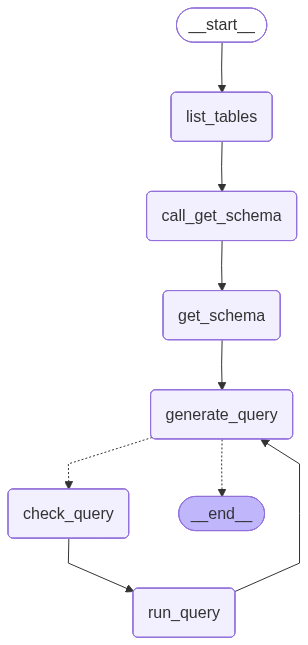

In [7]:
agent

In [8]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (e07b4ad6-63ab-4e46-93b9-a5ce9efe3440)
 Call ID: e07b4ad6-63ab-4e46-93b9-a5ce9efe3440
  Args:
    table_names: Genre, Track
================================= Tool Message =================================
Name: sql_db_schema

CREATE TABLE [Genre]
(
    [GenreId] INTEGER  NOT NULL,
    [Name] NVARCHAR(120),
    CONSTRAINT [PK_Genre] PRIMARY KEY  ([GenreId])
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Metal
*/

CREATE TABLE [Track]
(
    [TrackId] INTEGER  NOT NULL,
    [Name] NVARCHAR(200)  NOT NULL,
    [AlbumId] INTEGER,
    [MediaTy

Human in the loop

In [9]:
from langchain.tools import tool
from langgraph.types import interrupt
from langchain_core.runnables import RunnableConfig


@tool(
    run_query_tool.name,
    description=run_query_tool.description,
    args_schema=run_query_tool.args_schema,
)
def run_query_tool_with_interrupt(config: RunnableConfig, **tool_input):
    request = {
        "action": run_query_tool.name,
        "args": tool_input,
        "description": "Please review the tool call",
    }
    response = interrupt([request])
    # approve the tool call
    if response["type"] == "accept":
        tool_response = run_query_tool.invoke(tool_input, config)
    # update tool call args
    elif response["type"] == "edit":
        tool_input = response["args"]["args"]
        tool_response = run_query_tool.invoke(tool_input, config)
    # respond to the LLM with user feedback
    elif response["type"] == "response":
        user_feedback = response["args"]
        tool_response = user_feedback
    else:
        raise ValueError(f"Unsupported interrupt response type: {response['type']}")

    return tool_response


# Redefine the tool node to use the interrupt version
run_query_node = ToolNode([run_query_tool_with_interrupt], name="run_query")

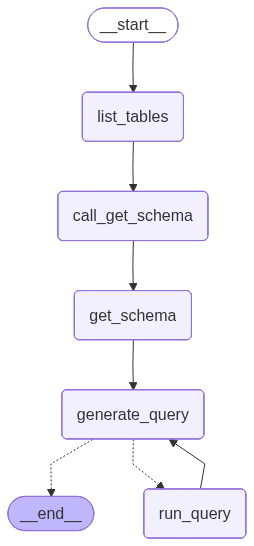

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

def should_continue(state: MessagesState) -> Literal[END, "run_query"]:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "run_query"

builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("run_query", "generate_query")

checkpointer = InMemorySaver()
agent = builder.compile(checkpointer=checkpointer)
agent

In [14]:
config = {"configurable": {"thread_id": "1"}}

In [16]:
import json
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    config,
    stream_mode="values",
):
    if "__interrupt__" in step:
        action = step["__interrupt__"][0]
        print("INTERRUPTED:")
        for request in action.value:
            print(json.dumps(request, indent=2))
    elif "messages" in step:
        step["messages"][-1].pretty_print()
    else:
        raise ValueError(f"Unsupported stream step type: {type(step)}")

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (ef8a413a-ea99-4fc5-8999-3e416d57d2a4)
 Call ID: ef8a413a-ea99-4fc5-8999-3e416d57d2a4
  Args:
    table_names: Genre, Track
================================= Tool Message =================================
Name: sql_db_schema

CREATE TABLE [Genre]
(
    [GenreId] INTEGER  NOT NULL,
    [Name] NVARCHAR(120),
    CONSTRAINT [PK_Genre] PRIMARY KEY  ([GenreId])
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Metal
*/

CREATE TABLE [Track]
(
    [TrackId] INTEGER  NOT NULL,
    [Name] NVARCHAR(200)  NOT NULL,
    [AlbumId] INTEGER,
    [MediaTy

In [17]:
from langgraph.types import Command

for step in agent.stream(
    Command(resume={"type": "accept"}),
    # Command(resume={"type": "edit", "args": {"query": "..."}}),
    config,
    stream_mode="values",
):
    if "__interrupt__" in step:
        action = step["__interrupt__"][0]
        print("INTERRUPTED:")
        for request in action.value:
            print(json.dumps(request, indent=2))
    elif "messages" in step:
        step["messages"][-1].pretty_print()
    else:
        raise ValueError(f"Unsupported stream step type: {type(step)}")

================================== Ai Message ==================================
Tool Calls:
  sql_db_query (b9691053-6b90-481e-8a8e-e0c775b12afb)
 Call ID: b9691053-6b90-481e-8a8e-e0c775b12afb
  Args:
    query: SELECT AVG(T.Milliseconds) AS AverageLength, G.Name FROM Track AS T JOIN Genre AS G ON T.GenreId = G.GenreId GROUP BY G.Name ORDER BY AverageLength DESC LIMIT 1
================================= Tool Message =================================
Name: sql_db_query

[(2911783.0384615385, 'Sci Fi & Fantasy')]
================================== Ai Message ==================================

On average, the 'Sci Fi & Fantasy' genre has the longest tracks.
